[![Fixel Algorithms](https://i.imgur.com/AqKHVZ0.png)](https://fixelalgorithms.gitlab.io)

# AI Program

## Scientific Python - Pandas

> Notebook by:
> - Royi Avital RoyiAvital@fixelalgorithms.com

## Revision History

| Version | Date       | User        |Content / Changes                                                   |
|---------|------------|-------------|--------------------------------------------------------------------|
| 0.1.002 | 28/03/2026 | Royi Avital | Accessing Series                                                   |
| 0.1.002 | 04/02/2024 | Royi Avital | Accessing Data Frame                                               |
| 0.1.001 | 28/02/2024 | Royi Avital | Added some notes according to class                                |
| 0.1.000 | 16/02/2024 | Royi Avital | First version                                                      |

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FixelAlgorithmsTeam/FixelCourses/blob/master/AIProgram/2024_02/0025Pandas.ipynb)

In [1]:
# Import Packages

# General Tools
import numpy as np
import scipy as sp
import pandas as pd

# Image Processing

# Machine Learning

# Miscellaneous
import os
from platform import python_version
import random

# Typing
from typing import Callable, List, Tuple

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter
from IPython import get_ipython

## Notations

* <font color='red'>(**?**)</font> Question to answer interactively.
* <font color='blue'>(**!**)</font> Simple task to add code for the notebook.
* <font color='green'>(**@**)</font> Optional / Extra self practice.
* <font color='brown'>(**#**)</font> Note / Useful resource / Food for thought.

Code Notations:

```python
someVar    = 2; #<! Notation for a variable
vVector    = np.random.rand(4) #<! Notation for 1D array
mMatrix    = np.random.rand(4, 3) #<! Notation for 2D array
tTensor    = np.random.rand(4, 3, 2, 3) #<! Notation for nD array (Tensor)
tuTuple    = (1, 2, 3) #<! Notation for a tuple
lList      = [1, 2, 3] #<! Notation for a list
dDict      = {1: 3, 2: 2, 3: 1} #<! Notation for a dictionary
oObj       = MyClass() #<! Notation for an object
dfData     = pd.DataFrame() #<! Notation for a data frame
dsData     = pd.Series() #<! Notation for a series
hObj       = plt.Axes() #<! Notation for an object / handler / function handler
```

### Code Exercise

 - Single line fill

```python
valToFill = ???
```

 - Multi Line to Fill (At least one)

```python
# You need to start writing
?????
```

 - Section to Fill

```python
#===========================Fill This===========================#
# 1. Explanation about what to do.
# !! Remarks to follow / take under consideration.
mX = ???

?????
#===============================================================#
```

In [2]:
# Configuration
# %matplotlib inline

seedNum = 512
np.random.seed(seedNum)
random.seed(seedNum)

# Matplotlib default color palette
lMatPltLibclr = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_theme() #>! Apply SeaBorn theme

runInGoogleColab = 'google.colab' in str(get_ipython())

In [3]:
# Constants

FIG_SIZE_DEF    = (8, 8)
ELM_SIZE_DEF    = 50
CLASS_COLOR     = ('b', 'r')
EDGE_COLOR      = 'k'
MARKER_SIZE_DEF = 10
LINE_WIDTH_DEF  = 2

In [ ]:
# Courses Packages


In [ ]:
# General Auxiliary Functions


## Pandas

[_Pandas_](https://github.com/pandas-dev/pandas) is the _go to_ data frame package in the Python eco system.

![](https://i.imgur.com/tFl2Tob.png)

The concept of a _Data Frame_ is to imitate data as represented in tabular data (Think _Excel_).  
Each row is a sample (The subject of the collection), Each column is a variable.  
This expands the uniformity of _NumPy_ arrays with more flexibility yet retains most of the performance.

It has an optimized methods to work on _data series_ (1D) and _data frame_ (2D).  
It relies on NumPy for most of the numeric operations and has a synergy with SeaBorn as the visualization tool.

* <font color='brown'>(**#**)</font> The package [`polars`](https://github.com/pola-rs/polars/) is a competitor of _Pandas_.  
It offers better performance and gaining popularity. Yet it is not a drop in replacement.
* <font color='brown'>(**#**)</font> Advanced tips for Pandas: [4 Pandas Anti Patterns to Avoid and How to Fix Them](https://www.aidancooper.co.uk/pandas-anti-patterns).

### SeaBorn

The Python package [`seaborn`](https://seaborn.pydata.org) is a statistical data visualization library.  
It wraps up _Matplotlib_ with beautiful recipes and useful tools.  
It has a big synergy with _Pandas_' data frame object.

## Series / Data Frame Construction

There are few common methods to generate a _DataFrame_:

1. From a File  
   A file format which handles multi format data.  
   In many cases for small scale data it will be a `csv` file.
2. From a Data Structure  
   One can generate a data frame from a `list`, `dictionary` or `np.ndarray`.

This section shows some of those cases.

In [10]:
# Generate a Series from a List

numSamples: int = 10
lA: List[float] = [random.random() for ii in range(numSamples)]
lA_rounded: List[float] = [round(item, 2) for item in lA]
print(f'lA: {lA}')
print(f'lA_rounded : {lA_rounded}')
dsA = pd.Series(lA_rounded) # creation of pd.series

# Display the series
# Pay attention to the index (See dsA.index)
dsA

lA: [0.835785590707858, 0.29046876224088014, 0.914333884132136, 0.8729303214706569, 0.8904357722508105, 0.8961083608747129, 0.23455357927857745, 0.6836381626549973, 0.7763068007786934, 0.22758156330804036]
lA_rounded : [0.84, 0.29, 0.91, 0.87, 0.89, 0.9, 0.23, 0.68, 0.78, 0.23]


0    0.84
1    0.29
2    0.91
3    0.87
4    0.89
5    0.90
6    0.23
7    0.68
8    0.78
9    0.23
dtype: float64

In [15]:
dsA = dsA.reindex(range(5, 15))
dsA

5     0.90
6     0.23
7     0.68
8     0.78
9     0.23
10     NaN
11     NaN
12     NaN
13     NaN
14     NaN
dtype: float64

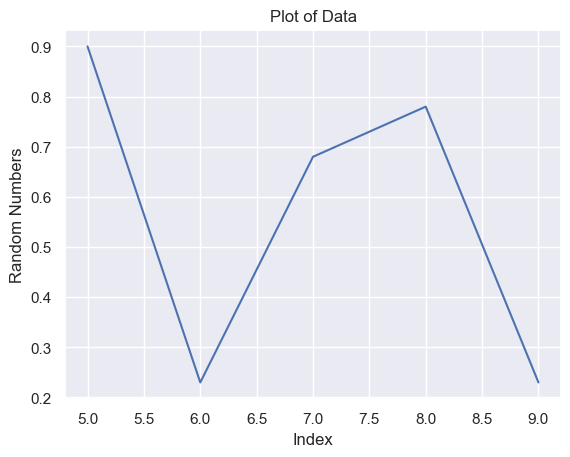

In [16]:
# Name the Series
# Each series has a `name` field.
# The name property is used by SeaBorn.

dsA.name = 'Random Numbers'
dsA.index.name = 'Index'
hA = sns.lineplot(dsA)
hA.set_title('Plot of Data');

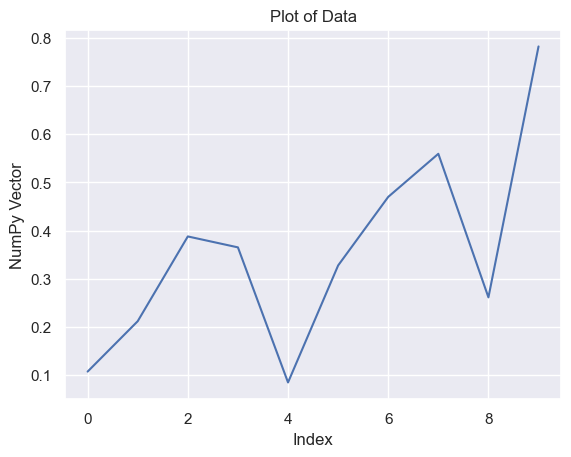

In [17]:
# Generate a Series from NumPy
dsB = pd.Series(np.random.rand(numSamples))
dsB.name = 'NumPy Vector'
dsB.index.name = 'Index'
hA = sns.lineplot(dsB)
hA.set_title('Plot of Data');

In [18]:
# Generate Data from a Dictionary

dA = {ii: random.random() for ii in range(5, 5 + numSamples)} #<! Full control of the index
dsC = pd.Series(dA)
dsC.rename('Dictionary', inplace = True)
dsC.index.rename('Index', inplace = True)

dsC

Index
5     0.792769
6     0.511044
7     0.066559
8     0.266102
9     0.080312
10    0.328388
11    0.559516
12    0.886609
13    0.241648
14    0.618970
Name: Dictionary, dtype: float64

In [ ]:
# The Index
# The index is arbitrary

dsC.index = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
dsC.index.name = 'Letter'

hA = sns.lineplot(dsC)
hA.set_title('Plot of Data');

In [ ]:
# Using ReIndex
# The `reindex()` uses extrapolation logic

dA = {ii: random.random() for ii in range(5, 5 + numSamples)} #<! Full control of the index
dsC = pd.Series(dA)
dsC.rename('Dictionary', inplace = True)
dsC.index.rename('Index', inplace = True)

dsC.reindex(range(numSamples))

In [ ]:
# Accessing Series by Index

dA = {ii: random.random() for ii in range(5, 5 + numSamples)} #<! Full control of the index
dsC = pd.Series(dA)
dsC.rename('Dictionary', inplace = True)
dsC.index.rename('Index', inplace = True)

print(dsC[9])
dsC.index = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
dsC.index.name = 'Letter'
print(dsC['J'])

In [ ]:
# Generate a Data Frame from NumPy Array

numRows = 7
numCols = 3

mA  = np.random.rand(numRows, numCols)
dfA = pd.DataFrame(mA)
dfA.columns = [f'Series {ii: 02d}' for ii in range(numCols)]
dfA.index.name = 'Idx'
dfA

In [ ]:
# Plotting the Data Frame

hA = sns.lineplot(dfA)
hA.set_title('Data Frame');

In [ ]:
# Data Frame from Dictionary
# In this case the keys are the name of the series (Columns)
dB = {'Series A': np.random.rand(numRows), 'Series B': np.random.rand(numRows), 'Series C': np.random.rand(numRows)}
dfB = pd.DataFrame(dB)
hA = sns.lineplot(dfB)
hA.set_title('Data Frame');

In [19]:
# Data from CSV
# Pandas can read CSV data from **URL**'s and local files

diamondsCsvUrl  = r'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv'
dfDiamonds      = pd.read_csv(diamondsCsvUrl)
dfDiamonds #<! Shows some rows

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


* <font color='brown'>(**#**)</font> Accessing a data frame:
  - Using columns name: `dfData['colName']`.
  - Using the `loc` accessor: `dfData.loc[vIndx, lCol]`.
  - Using the `iloc` accessor: `dfData.iloc[vLinIndx, lLinCol]`.

* <font color='brown'>(**#**)</font>  Any 1D slice of a data frame will yield a series. Even if it not homogenous. 

In [ ]:
# Access by Column Name
dfDiamonds['cut'] #<! Generates Series

In [ ]:
# Access by Column Name

dfDiamonds[['cut', 'color']] #<! Generates DataFrame

In [ ]:
# Access by `loc` as 2D Data Structure

dfDiamonds.loc[0, 'cut'] #<! Scalar
dfDiamonds.loc[:, 'cut'] #<! Series
dfDiamonds.loc[0, :] #<! Series
dfDiamonds.loc[[0, 1], :] #<! Data Frame

In [ ]:
# Access by `iloc` as 2D Data Structure
# Access by Memory Pattern or as if the index is reset

dfDiamonds.iloc[0, 1] #<! Scalar
dfDiamonds.iloc[:, 1] #<! Series
dfDiamonds.iloc[0, :] #<! Series
dfDiamonds.iloc[[0, 1], :] #<! Data Frame

In [ ]:
# Apply Reduction on an Axis
dfDiamonds[['x', 'y']].min(axis = 1)

## The Diamonds Data Set

The _Diamonds Data Set_ is a known data set which will be used to demonstrate some of the capabilities of _Pandas_.  
This section basically does [_EDA_](https://en.wikipedia.org/wiki/Exploratory_data_analysis) (Exploratory Data Analysis).

A great resource about data visualization is [Data to Viz](https://www.data-to-viz.com/).  
It suggests some guidelines on data visualization.

The variables are:

 - _Carat_  
   Carat is a metric that is used to measure the weight of a diamond. One carat is equivalent to 200mg. Diamond prices increase with diamond carat weight, which means bigger the diamond higher the price. If two diamonds weights are equal, then other features are used to determine the price. 
 - _Cut_  
   The goal is to cut a diamond within an appropriate size shape, and angle such that the light entering the diamond should reflect and leave from the top surface.  
   The values are Ideal, Premium, Good, Very Good, Fair.  
   This feature is an important thing to notice in a diamond as it measures three crucial things, such as:
    - Brilliance: It means the brightness of a diamond by the reflection of white lights inside and outside of a diamond.
    - Fire: It means Scattering of white light into all the colors of the rainbow.
    - Scintillation: the amount of sparkle produced and the pattern of light and dark areas caused by reflection within a diamond.    
 - _Color_  
   Color measurement in diamond measures lacks color. If the diamond color is like a drop of water that is colorless, it will have a high value. As then only it can scatter the light without observing. However, there are some diamonds that are in different colors will have higher prices.  
   The color scale is categorized from D to Z letters and ordered in ascending by the amount of presence of color in a diamond. From the K onwards to till Z, we can see a yellowish color present.  
   D ,E,F - Colorless G,H,I,J - Near colorlessness K, L, M - Faint color N-R: Very Light Color S-Z: light color.
 - _Clarity_   
   Diamonds are generated from sheer pressure and heat below the ground. Therefore, there will be some inclusion inside a diamond i.e., a mark or line pattern inside a diamond. Also, there will be a mark or line in the outer layer of a diamond, which is called blemishes. Based on the amount of inclusion and blemishes, the clarity of a diamond is categorized such as FL, IF, VSS1, VSS2, VS1, VS2, SI1, SI2, I1, I2, I3. The categories mentioned above are ordered in descending order by the amount of presence of inclusion and blemishes. 
 - _Depth_ [%]  
   Depth is the distance from a top surface i.e., table to a culet. The depth percentage is calculated by dividing the diamond depth by the overall width of a diamond. Lower the depth percentage the bigger the diamond looks from the below i.e., pavilion.
 - _Table_ [%]  
   The table is the topmost surface of a diamond and also the most significant facet of the round diamond. An appropriate width of a table will allow the light to enter and reflect on the appropriate direction .if not most of the light will scatter off in different directions. The table percentage is calculated by dividing the table width by overall diamond width.
 - _x_ / _y_ / _z_ [Mili Meter]  
   The dimension of a diamond is measured in millimeters. Moreover, the shape of a diamond is determined by the Length to width ratio. For instance, to determine the roundness of a diamond, we need to check the L/W ratio, If the ratio is between 1 and 1.05, it is a round diamond, and an oval shape diamond L/W ratio can be around 1.50 or less.  
   `x` -> Length, `y` -> width, `z` -> depth.

For more information look at [Diamonds Data Set](https://raw.githubusercontent.com/rithwiksarma/EDA-and-Classification---Diamonds-Dataset/main/updated-Diamonds-Project.pdf).


In [ ]:
# Change the Columns Name
dColName = {'carat': 'Carat', 'cut': 'Cut', 'color': 'Color', 'clarity': 'Clarity', 'depth': 'Depth Ratio', 'table': 'Table Ratio', 'price': 'Price [$]', 'x': 'Length', 'y': 'Width', 'z': 'Depth'}

#===========================Fill This===========================#
# 1. Read about `pd.DataFrame.rename()`.
# 2. Use the dictionary `dColName` to rename the columns name.
# !! Pay attention to the `inplace` parameter.
# !! An alternative could be done using the `DataFrame.columns` alternative.

dfDiamonds.rename(columns = dColName, inplace = True)

#===============================================================#

print(f'The columns are given by: {dfDiamonds.columns}')

### Type of Data

In Machine Learning we usually have several types:

- Continuous  
  The variables has a continuous value.  
  It might be be bounded or unbounded.
- Categorical  
  Values within a finite set of values.  
  Usually strings are mapped into categorical values.  
  Binary variable is a specific case of categorical variable.

* <font color='brown'>(**#**)</font> There could be an unbounded integer variable. It can be handled as either by a pre processing.
* <font color='brown'>(**#**)</font> A sub case of the _Categorical_ types is the _Ordinal_ type. Which is discrete and ordered.

In [ ]:
# Show Info of the Data Frame

print(f'The DF Shape is: {dfDiamonds.shape}')
print(f'The DF variables info: {dfDiamonds.info()}')

* <font color='brown'>(**#**)</font> The `Price [$]` is integer. In this context it is a non negative continuous variable.

In [ ]:
# The Type of Data
dVarType = {colName: 'Categorical' if dfDiamonds.dtypes[colName] == np.dtypes.ObjectDType else 'Continuous' for colName in dfDiamonds.columns}

In [ ]:
# The Values
# Each column is a series with the given methods in: https://pandas.pydata.org/docs/reference/series.html

for colName in dfDiamonds:
    varType = dVarType[colName]
    if varType == 'Categorical':
        print(f'The {colName} variable is {varType} with values: {dfDiamonds[colName].unique()}')
    else:
        print(f'The {colName} variable is {varType} with values: [{dfDiamonds[colName].min()}, {dfDiamonds[colName].max()}]')

In [ ]:
# Pandas Describe

dfDiamonds.describe()

In [ ]:
# The Depth Ratio
# The `Depth Ratio` is basically the Depth / Mean(Length, Width).
# This section show that numerically each columns behaves as a NumPy vector.

#===========================Fill This===========================#
# 1. Read about `pd.DataFrame.mean()`.
# 2. Calculate the value (Data Series)  Depth / Mean(Length, Width).
# 3. Save it as `dsDepthRatio`.
# !! The ratio should be given in [%].

dsDepthRatio = (dfDiamonds['Depth'] / dfDiamonds[['Length', 'Width']].mean(axis = 1)) * 100
#===============================================================#

dsDepthRatio.name = 'Depth Ratio Calculated'
dfTmp = pd.concat((dfDiamonds['Depth Ratio'], dsDepthRatio), axis = 1) #<! Concatenation of DF / DS into DF
dfTmp

In [ ]:
# Visualize Using SeaBorn

hF, hA = plt.subplots(figsize = (12, 8))
sns.lineplot(dfTmp, ax = hA) #<! SeaBorn can plot on a given axes
hA.set_title('Depth Ratio: Given vs. Calculated');

* <font color='red'>(**?**)</font> Is there a perfect match between the calculated values and the given ones? Explain.
* <font color='blue'>(**!**)</font> Find the cases and explain the reason.

### Pandas Grouping and Aggregation

* <font color='brown'>(**#**)</font> See [Chris Moffitt - Comprehensive Guide to Grouping and Aggregating with Pandas](https://pbpython.com/groupby-agg.html).

In [ ]:
# Group By
# The concept of `groupby` is creating a sub group matched by some criteria.  
# It is a powerful concept of DF which is heavily used in pipelines.

# Group Data by `Cut` and print its mean value and median value
dfGrpByCut = dfDiamonds.groupby(['Cut'])
print(f'The mean value by Cut: {dfGrpByCut["Price [$]"].mean()}')
print(f'The median value by Cut: {dfGrpByCut["Price [$]"].median()}')

# GroupBy are iterable: 
# - http://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html
# - https://stackoverflow.com/questions/27405483

In [ ]:
# Discretize the Carat Variable
dfTmp = dfDiamonds.copy()

In [ ]:
# Visualize a Violin Plot of the Price
# SeaBorn handles the grouping on its own.

hF, hA = plt.subplots(figsize = (12, 8))
sns.violinplot(dfDiamonds, x = 'Cut', y = 'Price [$]')
hA.set_title('Price Distribution Grouped by Cut');

* <font color='blue'>(**!**)</font> Read and change the parameters `density_norm` and `common_norm` in the violin plot.
* <font color='brown'>(**#**)</font> You may read on the [_Interquartile Range_](https://en.wikipedia.org/wiki/Interquartile_range) (IQR).

In [ ]:
# Pie Chart of the Cuts

hF, hA = plt.subplots(figsize = (6, 6))
hA.pie(dfDiamonds['Cut'].value_counts(), labels = dfDiamonds['Cut'].unique(), autopct = '%1.1f%%')
hA.set_title('Ratio of Diamonds per Cut');

In [ ]:
# Extract the Numerical Data (Continuous)

#===========================Fill This===========================#
# 1. Create a new DF which is composed only be the continuous values.
# 2. Name it `dfDiamondsCont`.
# !! Try to avoid doing it manually or by an explicit loop.

dfDiamondsCont = dfDiamonds[[key for key in dVarType.keys() if dVarType[key] == 'Continuous']]
#===============================================================#

* <font color='brown'>(**#**)</font> The correlation, between numerical variables, should be interpreted, in this context, as the _quality_ of the linear regressor between the 2 columns.
* <font color='red'>(**?**)</font> Given there are 7 columns, what will be the size of the correlation matrix? What's special about its structure?

In [ ]:
# Correlation Heatmap
# Dimensions of the correlation
# Correlation as Linear Estimator

hF, hA = plt.subplots(figsize = (12, 6))
sns.heatmap(dfDiamondsCont.corr().abs(), annot = True, linewidths = 8, center = 0, ax = hA)
hA.set_title('Correlation');

* <font color='red'>(**?**)</font> Any better way to handle the categorical data?

### Numeric Categorical Data

At the end, most algorithms require data to be numeric.  
Hence the need to convert non numeric _categorical data_ into numeric form.

Usually it is done in 2 steps:

1. Convert data into numeric form.
2. Set the colum to _categorical_ using `astype('category')`.

There are 2 main approaches to the the conversion into numeric form:

1. Dummy Variables (_One Hot Encoding_)  
   Any data can be represented by binary flags.  
   It will be `True` for its value and `False` for any other option.  
   The different values will be transformed into `Columns`.
2. Labels  
   Data will be mapped to numeric values (Integers) which are labels.  
   If order has some significance, it should be preserved.

In [ ]:
# Map the Strings into Numerical Values
# Using Pandas' `map()` function the strings will be mapped into values.
# If the order matters, the mapping should preserve it (Think of Clarity as a quality).

dClarityMap = {strClarity: ii for ii, strClarity in enumerate(dfDiamonds['Clarity'].unique())} #<! In practice, better choose values with meaning
dColorMap   = {strColor: ii for ii, strColor in enumerate(dfDiamonds['Color'].unique())}

dfDiamondsCat = dfDiamonds.copy() #<! Otherwise, by Reference
dfDiamondsCat['Clarity']    = dfDiamondsCat['Clarity'].map(dClarityMap)
dfDiamondsCat['Color']      = dfDiamondsCat['Color'].map(dColorMap)

# Convert to Categorical
dfDiamondsCat['Clarity']    = dfDiamondsCat['Clarity'].astype('category')
dfDiamondsCat['Color']      = dfDiamondsCat['Color'].astype('category')

In [ ]:
# Create Dummy Variables (One Hot Encoding)
# Using Pandas' `get_dummies()` to map N values to N (Or N - 1) columns of binary variables.

dfCutDummies  = pd.get_dummies(dfDiamonds['Cut'])
dfDiamondsCat = pd.concat((dfDiamondsCat, dfCutDummies), axis = 1)
dfDiamondsCat.drop(columns = ['Cut'], inplace = True)
dfDiamondsCat

In [ ]:
# The Types
dfDiamondsCat.info()

* <font color='red'>(**?**)</font> Why can we use `N - 1` instead of `N`?
* <font color='red'>(**?**)</font> Could we use less columns for binary representation? Will it really work?
* <font color='brown'>(**#**)</font> Linear operators (As _classifiers_ / _regressors_) can not handle labeled categorical data.  


In [ ]:
# Correlation Heatmap

hF, hA = plt.subplots(figsize = (12, 6))
sns.heatmap(dfDiamondsCat.corr(), annot = True, linewidths = 8, center = 0, ax = hA)
hA.set_title('Correlation');

* <font color='red'>(**?**)</font> Does the above makes sense? In the context of values.

In [ ]:
# Price Distribution per Color

hF, hA = plt.subplots(figsize = (12, 8))
sns.boxplot(dfDiamonds, x = 'Color', y = 'Price [$]', hue = 'Color', palette = 'Set1', width = 0.3, order = ['D','E','F','G','H','I','J'])
hA.set_title('Price Distribution Grouped by Color');

In [ ]:
# Price Distribution per Clarity
# Change the density norm and common normalization.

hF, hA = plt.subplots(figsize = (12, 8))
sns.violinplot(dfDiamonds, x = 'Clarity', y = 'Price [$]', hue = 'Clarity', palette = 'Set1', inner = 'point', order = ['IF','VVS1','VVS2','VS1','VS2','SI1','SI2','I1'])
hA.set_title('Price Distribution Grouped by Clarity');

In [ ]:
# Tables - Counting Intersections

dfDiamondsTable = pd.crosstab(index = dfDiamonds['Cut'], columns = dfDiamonds['Clarity'])
dfDiamondsTable.plot(kind = 'bar', figsize = (10, 10), stacked = True);

In [ ]:
dfDiamondsTable = pd.crosstab(index = dfDiamonds['Color'], columns = dfDiamonds['Clarity'])
dfDiamondsTable.plot(kind = 'bar', figsize = (10, 10), stacked = True);

A nice EDA on the data is given in [Diamonds Price EDA and Prediction](http://portfolio.exmachinalabs.ai/notebooks/Diamonds.html) (Though it is in `R`).

* <font color='green'>(**@**)</font> Using slicing operations convert the following data frame:

```python
dIn = {'Col1': ['h', 'i', 'k', 'n'], 'Col2': ['a', 'v', 's', 'g'], 'Col3': ['t', 'i', 'g', 'n'], 'Col4': ['t', 'g', 'n', 'i']}
dfIn = pd.DataFrame(dIn)
dfIn
```

| Col1 | Col2 | Col3 | Col4 |
|-----:|-----:|-----:|-----:|
|    h |    a |    t |    t |
|    i |    v |    i |    g |
|    k |    s |    g |    n |
|    n |    g |    n |    i |

Into:

```python
dOut = {'Col1': ['t', 'n', 'g', 'i'], 'Col2': ['h', 'k', 'i', 'n'], 'Col3': ['a', 's', 'v', 'g']}
dfOut = pd.DataFrame(dOut)
dfOut
```

| Col1 | Col2 | Col3 |
|-----:|-----:|-----:|
|    t |    h |    a |
|    n |    k |    s |
|    g |    i |    v |
|    i |    n |    g |

See [SimplyStats Thanksgiving Puzzle](https://jcarroll.com.au/2015/11/26/simplystats-thanksgiving-puzzle).

In [ ]:
dOut = {'Col1': ['t', 'n', 'g', 'i'], 'Col2': ['h', 'k', 'i', 'n'], 'Col3': ['a', 's', 'v', 'g']}
dfOut = pd.DataFrame(dOut)
dfOut